# Profile Model

## PROJECT TITLE: Ensemble Machine Learning for Mitigating Payment Paralysis in Kenyan SMEs. 

A brand new client has no payment history, so the behaviour model has nothing to work with. This model uses only what a supplier can know about a business on day one: sector, number of employees and whether the business is under two years old.

Data: U.S. Small Business Administration loans, Li, Mickel and Taylor (2018), CC BY-SA 4.0.

# Install Dependencies and Import Required Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             precision_score, recall_score, f1_score)
import shap
SEED = 42
RAW, MODELS, FIGS = '../data/raw/', '../models/', '../reports/figures/'
os.makedirs(MODELS, exist_ok=True); os.makedirs(FIGS, exist_ok=True)

# Load only the columns we need

The dataset has 27 columns and about 900,000 loans. We load only sector (NAICS), approval year, number of employees, new or existing and the outcome. Bank, state, loan amount, term and guarantee columns are left out, because a supplier would not know them. ChgOffDate and ChgOffPrinGr are also left out because they are only known after a default. That would be leakage.

In [3]:
cols = ['NAICS', 'ApprovalFY', 'NoEmp', 'NewExist', 'MIS_Status']
sba = pd.read_csv(RAW + 'SBAnational.csv', usecols=cols, low_memory=False)
print(sba.shape)
print(sba.MIS_Status.value_counts(dropna=False))

(899164, 5)
MIS_Status
P I F     739609
CHGOFF    157558
NaN         1997
Name: count, dtype: int64


# Clean

Drop four groups of rows.

- Loans with no outcome.
- Loans with no sector code (NAICS 0).
- Loans with unknown business age.
- Loans outside 1995 to 2004. Earlier years are few. From 2005 onwards the financial crisis distorts default rates and many recent loans had not finished yet, so their outcome was not known.

In [4]:
sba['year'] = pd.to_numeric(sba.ApprovalFY.astype(str).str[:4], errors='coerce')
before = len(sba)
sba = sba[sba.MIS_Status.notna()]              # outcome unknown
sba = sba[sba.NAICS != 0]                      # sector unknown
sba = sba[sba.NewExist.isin([1, 2])]           # new or existing unknown
sba = sba[sba.year.between(1995, 2004)]        # stable years with finished loans
print(f'Kept {len(sba)} of {before} loans')
sba.groupby('year').MIS_Status.apply(lambda s: (s == 'CHGOFF').mean()).round(3)

Kept 318920 of 899164 loans


year
1995    0.027
1996    0.040
1997    0.057
1998    0.079
1999    0.092
2000    0.108
2001    0.119
2002    0.117
2003    0.146
2004    0.181
Name: MIS_Status, dtype: float64

# Features that match the dashboard

each SBA field matches a field in the app.

- Sector. The first two digits of NAICS are the industry. These map to the sector dropdown in the app.
- Business age. The SBA "new" means under two years old. This matches the app's "under 2 years" band.
- Size band. Employees are grouped into under 5, 5 to 20, 21 to 50 and over 50, the same bands as the app.

In [5]:
sba['target'] = (sba.MIS_Status == 'CHGOFF').astype(int)
sba['sector'] = sba.NAICS.astype(str).str[:2].astype(int)
sba['is_new_business'] = (sba.NewExist == 2).astype(int)
sba['size_band'] = pd.cut(sba.NoEmp, bins=[-1, 4, 20, 50, np.inf], labels=[0, 1, 2, 3]).astype(int)
FEATURES = ['sector', 'is_new_business', 'size_band']
for f in FEATURES:
    print(sba.groupby(f).target.agg(['count', 'mean']).round(3), '\n')

        count   mean
sector              
11       4234  0.101
21        775  0.055
22        350  0.077
23      25617  0.118
31       5528  0.128
32       8983  0.118
33      19003  0.095
42      23066  0.119
44      40582  0.137
45      21290  0.160
48       6326  0.150
49        963  0.138
51       5098  0.140
52       3642  0.120
53       4869  0.136
54      29097  0.094
55        168  0.012
56      14091  0.128
61       2447  0.128
62      27303  0.068
71       6816  0.130
72      32345  0.138
81      36211  0.117
92        116  0.069 

                  count   mean
is_new_business               
0                238912  0.117
1                 80008  0.127 

            count   mean
size_band               
0          164819  0.135
1          119296  0.110
2           26299  0.081
3            8506  0.064 



smaller businesses charged off more often. Sector and new versus existing make smaller differences.

# Split by year

Train on 1995 to 2002, calibrate on 2003 and test on 2004.

In [6]:
train = sba[sba.year <= 2002]
calib = sba[sba.year == 2003]
test = sba[sba.year == 2004]
for name, d in [('train', train), ('calibration', calib), ('test', test)]:
    print(f'{name:12s} {len(d):7d} rows, charged off {d.target.mean():.1%}')

train         192992 rows, charged off 9.0%
calibration    57843 rows, charged off 14.6%
test           68085 rows, charged off 18.1%


# Train and compare with the baseline

In [7]:
base = DummyClassifier(strategy='prior').fit(train[FEATURES], train.target)
rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=50, max_samples=0.3,
                            class_weight='balanced', n_jobs=-1, random_state=SEED).fit(train[FEATURES], train.target)
gb = HistGradientBoostingClassifier(class_weight='balanced', categorical_features=[0],
                                    random_state=SEED).fit(train[FEATURES], train.target)
for name, m in [('Baseline', base), ('Random Forest', rf), ('Gradient Boosting', gb)]:
    p = m.predict_proba(test[FEATURES])[:, 1]
    print(f'{name:18s} ROC-AUC {roc_auc_score(test.target, p):.3f}  PR-AUC {average_precision_score(test.target, p):.3f}')

Baseline           ROC-AUC 0.500  PR-AUC 0.181
Random Forest      ROC-AUC 0.551  PR-AUC 0.200
Gradient Boosting  ROC-AUC 0.550  PR-AUC 0.200


# Calibrate, then assign tiers

In [8]:
def calibrate(m):
    try:
        from sklearn.frozen import FrozenEstimator
        c = CalibratedClassifierCV(FrozenEstimator(m), method='isotonic')
    except ImportError:
        c = CalibratedClassifierCV(m, method='isotonic', cv='prefit')
    return c.fit(calib[FEATURES], calib.target)

best = gb if roc_auc_score(calib.target, gb.predict_proba(calib[FEATURES])[:, 1]) >= \
            roc_auc_score(calib.target, rf.predict_proba(calib[FEATURES])[:, 1]) else rf
best_cal = calibrate(best)
p = best_cal.predict_proba(test[FEATURES])[:, 1]
LOW, HIGH = 0.10, 0.30
tiers = np.where(p < LOW, 'Low', np.where(p < HIGH, 'Medium', 'High'))
print('Chosen model:', type(best).__name__)
print(f'ROC-AUC {roc_auc_score(test.target, p):.3f} | PR-AUC {average_precision_score(test.target, p):.3f} | Brier {brier_score_loss(test.target, p):.4f}')
print(pd.DataFrame({'tier': tiers, 'y': test.target.values}).groupby('tier').y.agg(['count', 'mean'])
      .reindex(['Low', 'Medium', 'High']).round(3))

Chosen model: RandomForestClassifier
ROC-AUC 0.555 | PR-AUC 0.202 | Brier 0.1482
          count   mean
tier                  
Low      8939.0  0.117
Medium  59146.0  0.190
High        NaN    NaN


ROC-AUC is about 0.55 and no client reaches the High tier. I also tried adding franchise status and a finer industry code and neither moved it above 0.56. So this is a real limit of profile data, not a tuning problem.



- Who a business is (sector, size, age) tells you little about whether it will pay.
- How it has paid before tells you a lot. The behaviour model reaches 0.68 and its history features dominate SHAP.
That is the strongest argument for the prototype itself. The most useful risk signal is already in the SME's own invoice book and the system turns it into a decision.

It also influences two rules in the dashboard, which is prescriptive analytics in action:

- A client with no settled invoices is never rated below Medium.
- Graduated credit for new clients. Start with a small order or a deposit and extend normal terms as invoices settle on time, until the behaviour model takes over at the third settled invoice.

# SHAP summary

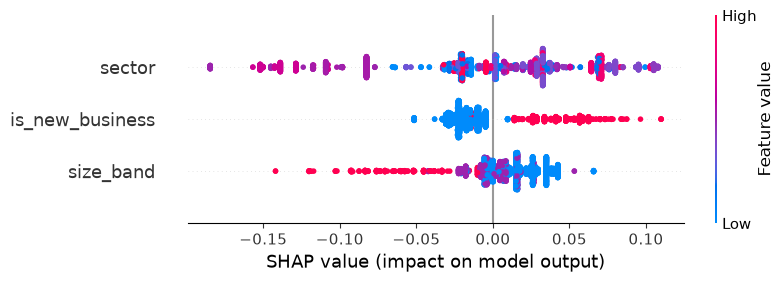

In [9]:
sample = test[FEATURES].sample(3000, random_state=SEED)
sv = shap.TreeExplainer(best)(sample)
if sv.values.ndim == 3:
    sv = sv[:, :, 1]
shap.plots.beeswarm(sv, show=False)
plt.savefig(FIGS + 'profile_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Save

In [10]:
joblib.dump({'model': best_cal, 'features': FEATURES, 'cutoffs': (LOW, HIGH)}, MODELS + 'profile_model.joblib')
print('Saved')

Saved
